## Goal

Here, we compare chromosome 8 of the human genome from X or Y-bearing sperm.

1) ~~Obtain eigenvector 1 (E1 track)~~
2) apply pymc model (train on data)
3) obtain confidence intervals
4) quantify differences

## Load the eigenvector tracks

In [1]:
import pandas as pd
from glob import glob
from pprint import pprint

# eig_paths = glob('../data/eigs/*chr8*')
eig_paths = glob('../data/eigs/*chr8.eigs.10000.*')
eig_paths

['../data/eigs/sperm_X.chr8.eigs.10000.cis.vecs.tsv',
 '../data/eigs/sperm_Y.chr8.eigs.10000.cis.vecs.tsv']

In [2]:
pd.read_csv(eig_paths[0], sep='\t', index_col=0).columns.str.lower()

Index(['start', 'end', 'weight', 'e1', 'e2', 'e3'], dtype='object')

In [3]:
resolutions = [eig_path.split('eigs.')[1].split('.cis')[0] for eig_path in eig_paths]
sex_chrom = [eig_path.split('_')[1].split('.')[0] for eig_path in eig_paths]

zipped = zip(resolutions, sex_chrom, eig_paths)

eigs_dict = {resolutions[i]: {sex_chrom[j]: eig_paths[j] for j in range(len(sex_chrom))} for i in range(len(eig_paths))}
pprint(eigs_dict)

{'10000': {'X': '../data/eigs/sperm_X.chr8.eigs.10000.cis.vecs.tsv',
           'Y': '../data/eigs/sperm_Y.chr8.eigs.10000.cis.vecs.tsv'}}


## A function to build the model from eigs_dict

In [4]:
import pymc as pm
import arviz as az
import numpy as np
import pytensor.tensor as pt

In [5]:

def build_model_from_config(path, cfg):
    """
    Build a PyMC model based on the provided configuration dictionary.
    """
    df = pd.read_csv(path, sep="\t")
    df.columns = df.columns.str.lower()
    df.dropna(inplace=True)
    e1 = df.e1.values 
    mean_negative = df.e1[df.e1 < 0].mean()
    mean_positive = df.e1[df.e1 > 0].mean()
    cfg['mu_mu'] = np.array([mean_negative, mean_positive])
    cfg['mu_sigma'] = np.array([df.e1[df.e1 < 0].std(), df.e1[df.e1 > 0].std()])
    
    with pm.Model(coords={"pos": df.start.values, "label": ["B", "A"]}) as model:
        # e1 = pm.Data("e1", df.e1.values, dims="pos")


        mu = pm.Normal("mu", mu=cfg['mu_mu'], sigma=cfg['mu_sigma'],
                       transform=pm.distributions.transforms.ordered, dims="label")
        sigma = pm.HalfNormal("sigma", sigma=cfg['sigma'], dims="label")

        # components: Normal or StudentT
        if cfg['comp_dist'] == "Normal":
            components = pm.Normal.dist(mu=mu, sigma=sigma, shape=2)
        else:
            components = pm.StudentT.dist(mu=mu, sigma=sigma, **cfg['comp_kwargs'], shape=2)

        # grw_sigma: HalfNormal or HalfStudentT
        if cfg['grw_sigma_dist'] == "HalfNormal":
            grw_sigma = pm.HalfNormal("grw_sigma", **cfg['grw_sigma_kwargs'])
        else:
            grw_sigma = pm.HalfStudentT("grw_sigma", **cfg['grw_sigma_kwargs'])

        # eps: Normal or StudentT
        if cfg['eps_dist'] == "Normal":
            eps = pm.Normal("eps", dims="pos", mu=0.0, sigma=1.0)
        else:
            eps = pm.StudentT("eps", dims="pos", mu=0.0, sigma=1.0, nu=cfg['eps_kwargs']['nu'])

        logit_w = pm.Deterministic("logit_w", pt.cumsum(eps*grw_sigma), dims="pos")
        w = pm.Deterministic("w", pm.math.sigmoid(logit_w), dims="pos")

        # Latent z variable
        z = pm.Bernoulli("z", p=w, dims="pos")


        y_hat = pm.Mixture("y_hat", w=pt.stack([1-z,z], axis=1), comp_dists=components,
                           observed=e1, dims='pos')

    return model

    

In [6]:
import json

with open("../results/model_grid.json", "r") as f:
    config_list = json.load(f)

configs = {cfg['name']: cfg for cfg in config_list}

name = "N_N_HN"

config = configs[name]
config['grw_sigma_kwargs'] = {'sigma': 0.005}
config

{'name': 'N_N_HN',
 'comp_dist': 'Normal',
 'comp_kwargs': {},
 'eps_dist': 'Normal',
 'eps_kwargs': {'mu': 0.0, 'sigma': 1.0},
 'grw_sigma_dist': 'HalfNormal',
 'grw_sigma_kwargs': {'sigma': 0.005},
 'mu_mu': [-0.5, 0.5],
 'mu_sigma': 0.3,
 'sigma': 0.3}

In [7]:
# If we were to run different architectures
cfg_sname = config['name'].replace('_','')

models = {}
# But we aren't 
for res, dic in eigs_dict.items():
    for chrom, path in dic.items():
        model_name = f"{int(res)/1000:.0f}kb.{chrom}" # Add .`cfg_sname` here if needed
        print(f"Processing res:{res} and chrom:{chrom} ::: {name}")
        print(path)
        models[model_name] = build_model_from_config(path, config)

print()
pprint(models)
        

Processing res:10000 and chrom:X ::: N_N_HN
../data/eigs/sperm_X.chr8.eigs.10000.cis.vecs.tsv


Processing res:10000 and chrom:Y ::: N_N_HN
../data/eigs/sperm_Y.chr8.eigs.10000.cis.vecs.tsv

{'10kb.X': <pymc.model.core.Model object at 0x14e294ecae40>,
 '10kb.Y': <pymc.model.core.Model object at 0x14e294f57390>}


graph TD
%% Nodes:
eps([eps ~ Normal])
eps@{ shape: rounded }
grw_sigma([grw_sigma ~ Halfnormal])
grw_sigma@{ shape: rounded }
logit_w([logit_w ~ Deterministic])
logit_w@{ shape: rect }
mu([mu ~ Normal])
mu@{ shape: rounded }
sigma([sigma ~ Halfnormal])
sigma@{ shape: rounded }
w([w ~ Deterministic])
w@{ shape: rect }
y_hat([y_hat ~ Mixture])
y_hat@{ shape: rounded }
style y_hat fill:#757575
z([z ~ Bernoulli])
z@{ shape: rounded }

%% Edges:
eps --> logit_w
grw_sigma --> logit_w
logit_w --> w
mu --> y_hat
sigma --> y_hat
z --> y_hat
w --> z

%% Plates:
subgraph "label (2)"
    sigma
    mu
end
subgraph "pos (13422)"
    logit_w
    y_hat
    eps
    w
    z
end


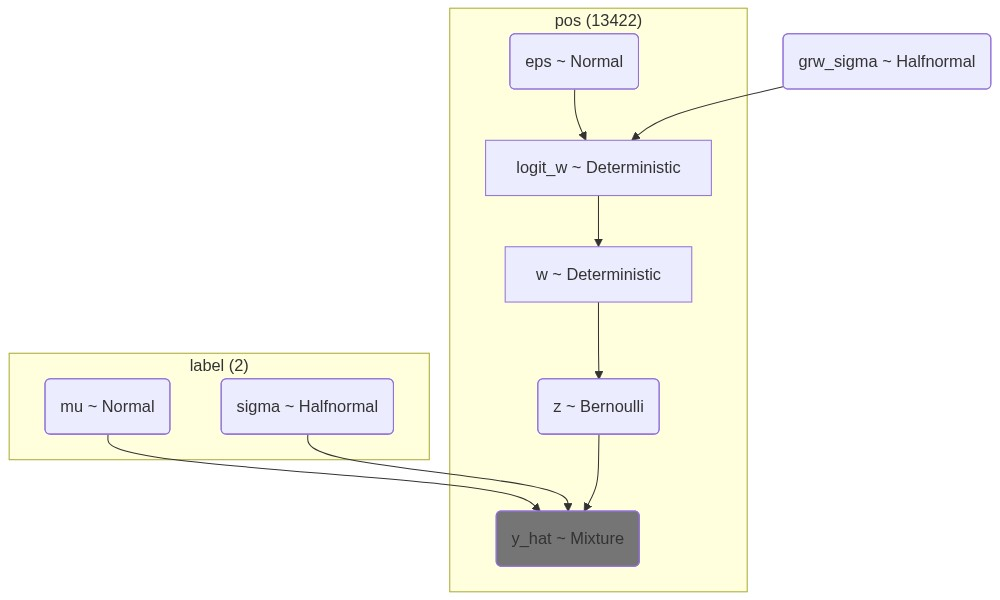

In [8]:
# Visualize model

from mermaid import Mermaid, Graph
from IPython.display import Image

mermaid = Graph('10kb_X', pm.model_to_mermaid(models['10kb.X']))
render = Mermaid(mermaid, width=1000, height=600)

print(mermaid.script)

display(Image(render.img_response.content, width=1000, height=600, retina=True))


In [9]:
# Sampling loop

from datetime import datetime

def log(msg, path=".12_chr8_compare_X_Y_model.log", overwrite=False):
    print(f"LOG: {msg}")
    if overwrite:
        with open(path, "w") as f:
            f.write(msg + "\n")
    else:
        with open(path, "a") as f:
            f.write(msg + "\n")


# Reset the log file
log("Resetting log... \n", overwrite=True)


for name,model in models.items():
    log(f"Sampling model: {name}")
    start = datetime.now()
    log(f"Started at {start.strftime('%H:%M:%S')}")
    with model:
        idata = pm.sample(draws=1000, tune=1000, chains=7, cores=7, progressbar=False)
        pm.compute_log_likelihood(idata, progressbar=False)
        prior_predictive = pm.sample_prior_predictive(1000)
        posterior_predictive = pm.sample_posterior_predictive(idata, progressbar=False)
    idata.extend(prior_predictive)
    idata.extend(posterior_predictive)
    log(f"--> Took {(datetime.now()-start).total_seconds()} seconds!\n")
    save_path  = f"../results/traces/12.chr8.{name}.trace.nc"
    idata.to_netcdf(save_path)
    log(f"Saved model {name} to {save_path}\n")

LOG: Resetting log... 

LOG: Sampling model: 10kb.X
LOG: Started at 12:40:52


Multiprocess sampling (7 chains in 7 jobs)


CompoundStep


>NUTS: [mu, sigma, grw_sigma, eps]


>BinaryGibbsMetropolis: [z]


...

The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Sampling: [eps, grw_sigma, mu, sigma, y_hat, z]


Sampling: [y_hat]


LOG: --> Took 40777.053371 seconds!



LOG: Saved model 10kb.Y to ../results/traces/12.chr8.10kb.Y.trace.nc



## Load back the traces

To be able to start from here

In [1]:
import arviz as az
import numpy as np

traces = {'10kb.X': az.from_netcdf(f"../results/traces/12.chr8.10kb.X.trace.nc"),
          '10kb.Y': az.from_netcdf(f"../results/traces/12.chr8.10kb.Y.trace.nc")}

traces['10kb.X']

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> prior
	> prior_predictive
	> observed_data

In [2]:
display(
    az.summary(traces['10kb.X'], var_names=["mu", "sigma", "grw_sigma"]),
    az.summary(traces['10kb.Y'], var_names=["mu", "sigma", "grw_sigma"])
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu[B],-0.007,0.004,-0.014,-0.000,0.000,0.0,5229.0,5830.0,1.00
mu[A],0.042,0.018,0.009,0.078,0.000,0.0,2567.0,2355.0,1.00
sigma[B],0.315,0.004,0.307,0.322,0.000,0.0,338.0,1022.0,1.01
sigma[A],0.821,0.020,0.783,0.857,0.001,0.0,328.0,979.0,1.01
grw_sigma,0.051,0.003,0.045,0.056,0.000,0.0,1956.0,3815.0,1.00


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu[B],-0.002,0.005,-0.011,0.006,0.000,0.001,140.0,65.0,1.04
mu[A],0.019,0.014,-0.004,0.042,0.003,0.000,24.0,67.0,1.20
sigma[B],0.377,0.162,0.300,0.779,0.061,0.062,17.0,24.0,1.34
sigma[A],0.705,0.161,0.307,0.795,0.060,0.061,16.0,25.0,1.34
grw_sigma,0.051,0.003,0.046,0.057,0.000,0.000,2401.0,3686.0,1.00


In [3]:
# get the w variable and stack for each model

w_vars = {name: trace.posterior.w.stack(sample=('chain', 'draw')) for name, trace in traces.items()}

for key,w in w_vars.items():
    print(f"Model: {key}")
    display(w)

Model: 10kb.X


<xarray.DataArray 'w' (pos: 13422, sample: 7000)> Size: 752MB
array([[0.49605762, 0.48834244, 0.5261243 , ..., 0.49360468, 0.50709713,
        0.49705415],
       [0.50060995, 0.50243063, 0.50522671, ..., 0.47965051, 0.48735011,
        0.50237799],
       [0.51536279, 0.4849344 , 0.49852954, ..., 0.47525455, 0.48662937,
        0.49215801],
       ...,
       [0.56441804, 0.54819182, 0.65741996, ..., 0.63149671, 0.53898454,
        0.37759843],
       [0.55674081, 0.56819849, 0.64913287, ..., 0.64677399, 0.55994291,
        0.38399866],
       [0.57180106, 0.59362441, 0.63944507, ..., 0.65832227, 0.58125147,
        0.39181879]], shape=(13422, 7000))
Coordinates:
  * pos      (pos) int64 107kB 210000 220000 230000 ... 139980000 139990000
  * sample   (sample) object 56kB MultiIndex
  * chain    (sample) int64 56kB 0 0 0 0 0 0 0 0 0 0 0 ... 6 6 6 6 6 6 6 6 6 6 6
  * draw     (sample) int64 56kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999

Model: 10kb.Y


<xarray.DataArray 'w' (pos: 13424, sample: 7000)> Size: 752MB
array([[0.4928388 , 0.50967689, 0.5140754 , ..., 0.51623385, 0.53183525,
        0.51005501],
       [0.51385253, 0.4991335 , 0.52678598, ..., 0.51183615, 0.52103139,
        0.51243554],
       [0.51889279, 0.50206728, 0.52922239, ..., 0.50576988, 0.52770751,
        0.51037902],
       ...,
       [0.66436691, 0.5814862 , 0.48354889, ..., 0.66987   , 0.51910925,
        0.66017438],
       [0.66849403, 0.56639594, 0.49466372, ..., 0.66387936, 0.50050684,
        0.67009629],
       [0.67030872, 0.55893933, 0.51660155, ..., 0.67218174, 0.52401456,
        0.64429321]], shape=(13424, 7000))
Coordinates:
  * pos      (pos) int64 107kB 210000 220000 230000 ... 139980000 139990000
  * sample   (sample) object 56kB MultiIndex
  * chain    (sample) int64 56kB 0 0 0 0 0 0 0 0 0 0 0 ... 6 6 6 6 6 6 6 6 6 6 6
  * draw     (sample) int64 56kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999

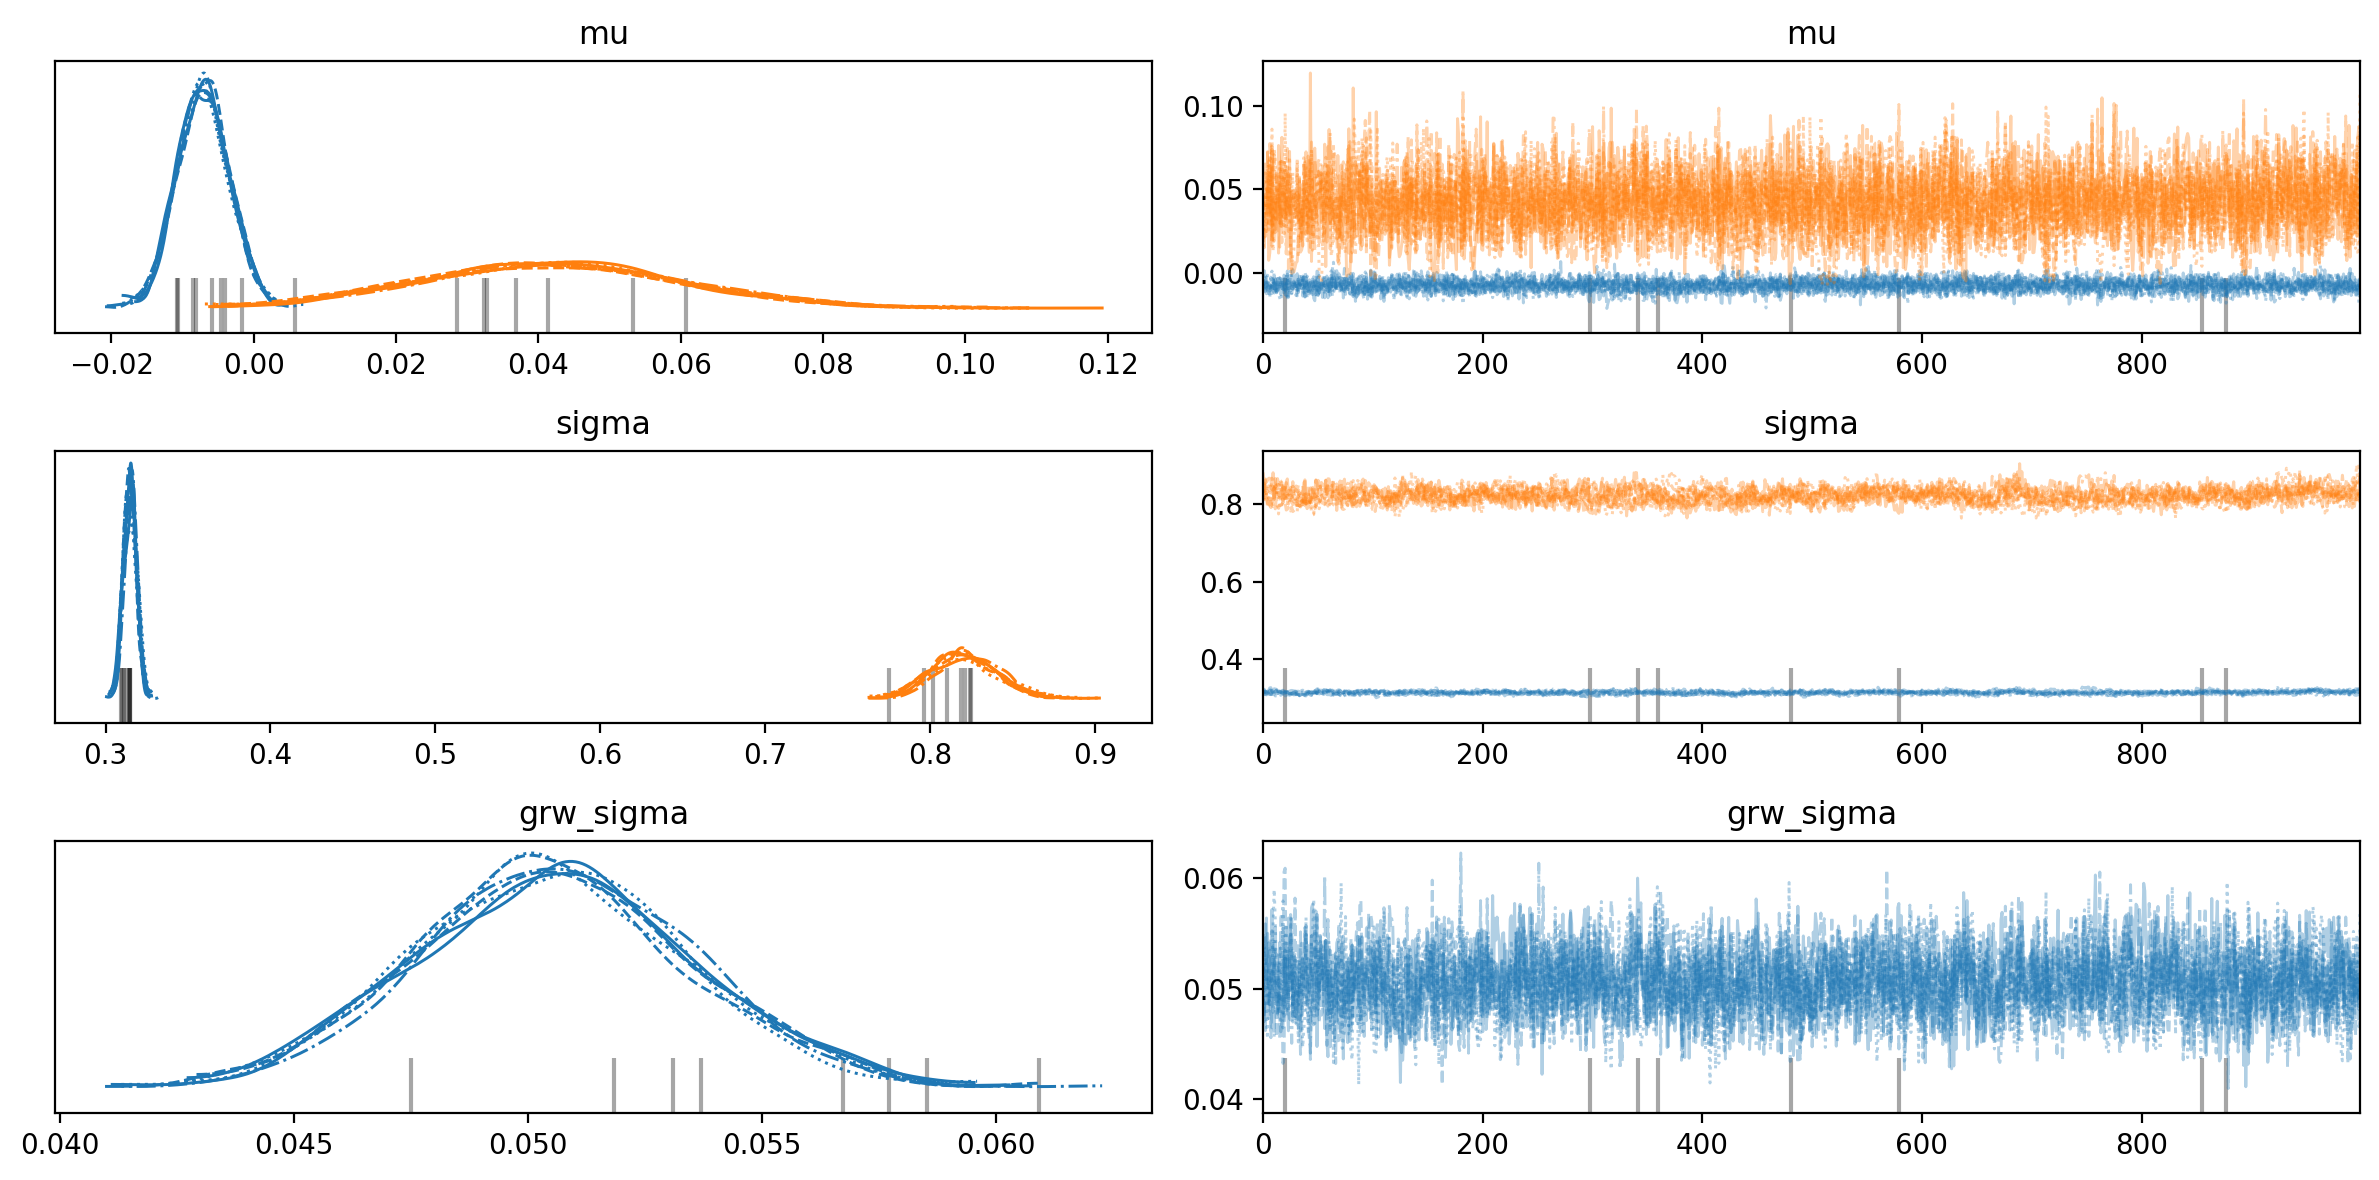

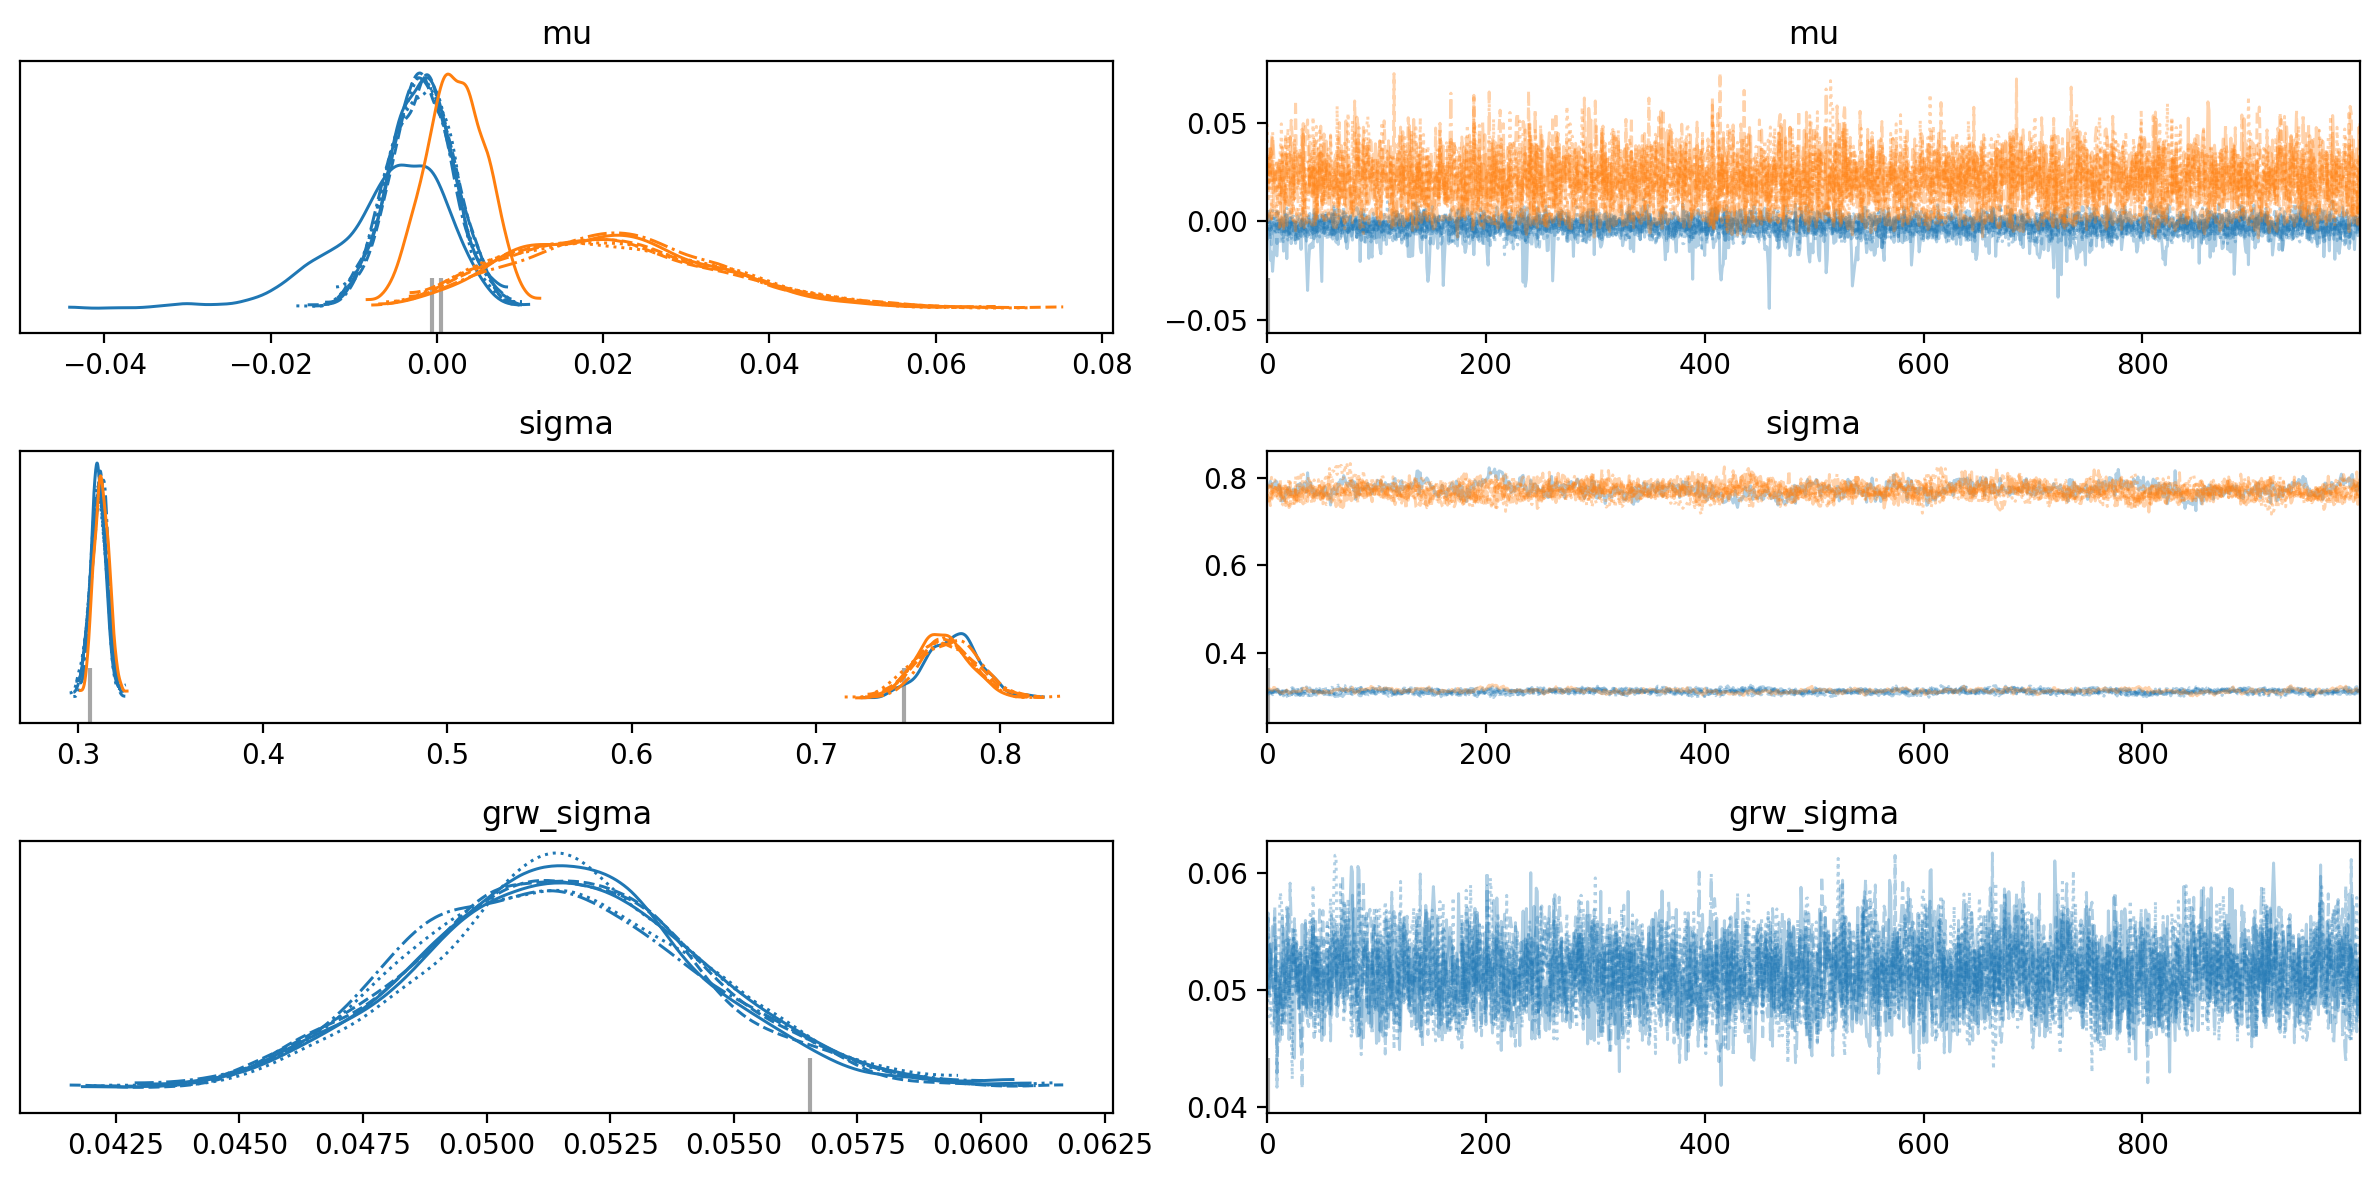

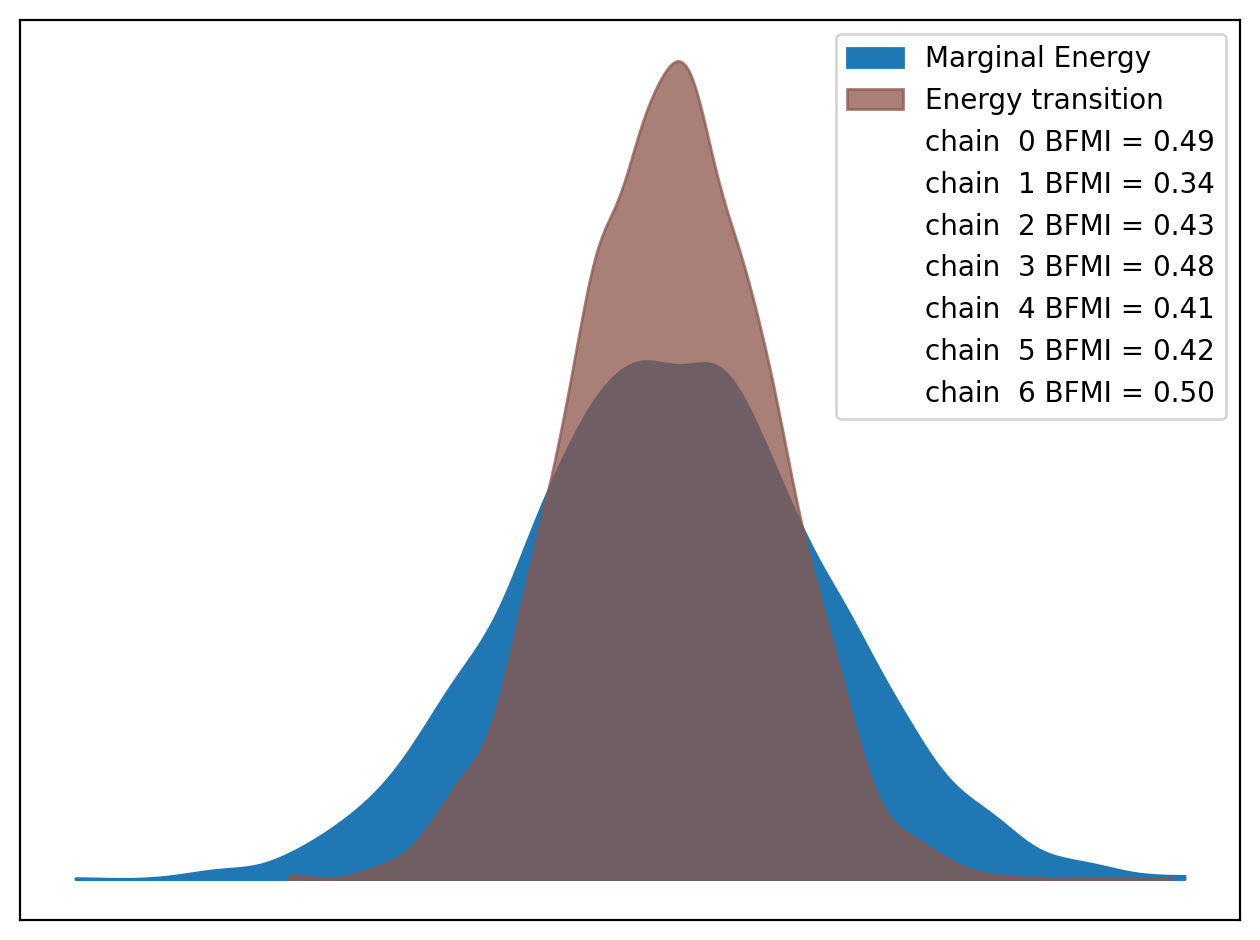

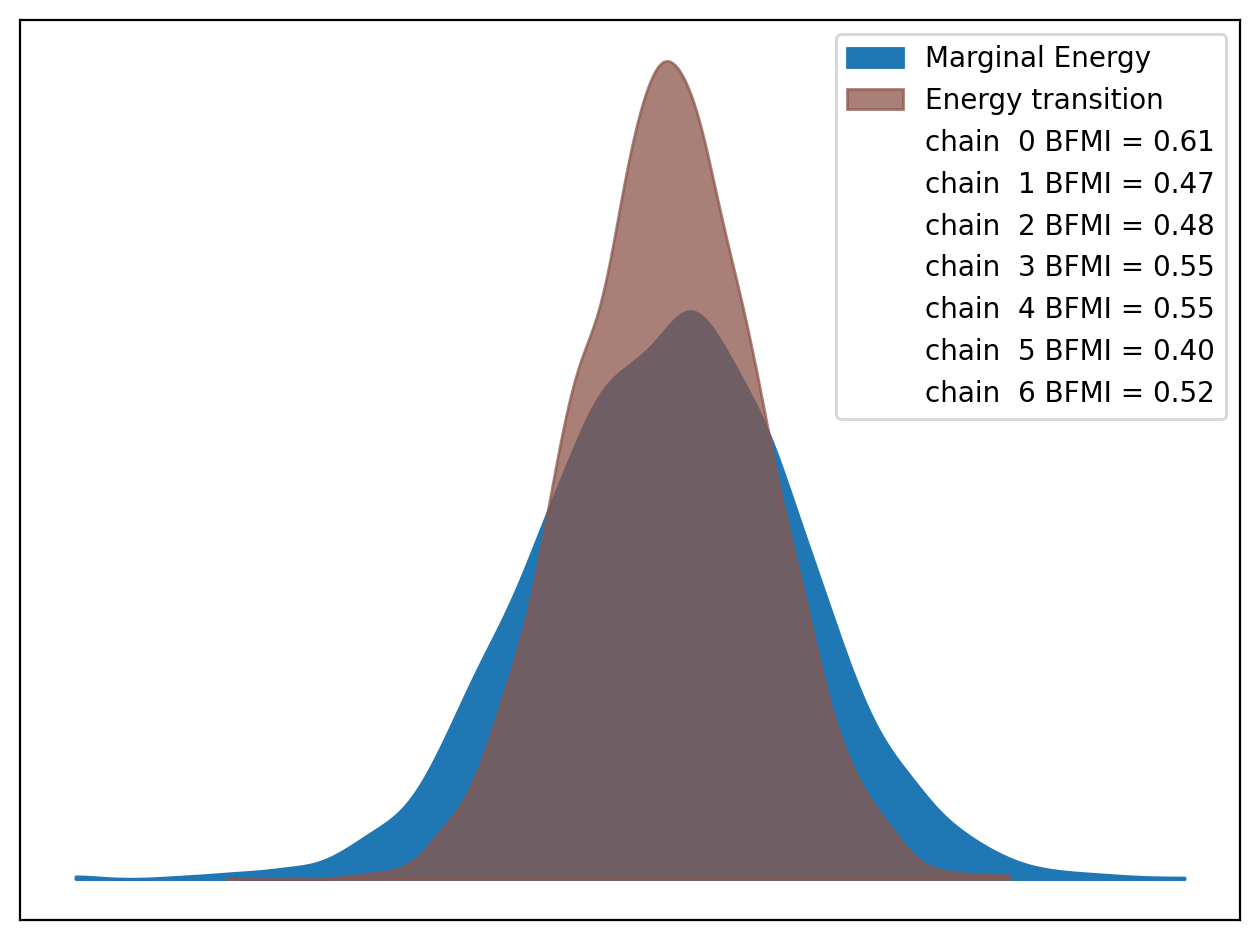

In [4]:
az.plot_trace(traces['10kb.X'], var_names=['mu', 'sigma', 'grw_sigma'], backend_kwargs={'layout': 'tight'}, compact=True);
az.plot_trace(traces['10kb.Y'], var_names=['mu', 'sigma', 'grw_sigma'], backend_kwargs={'layout': 'tight'}, compact=True);
az.plot_energy(traces['10kb.X'], backend_kwargs={'layout': 'tight'});
az.plot_energy(traces['10kb.Y'], backend_kwargs={'layout': 'tight'});

Model: 10kb.X, non-empty bins: 13422


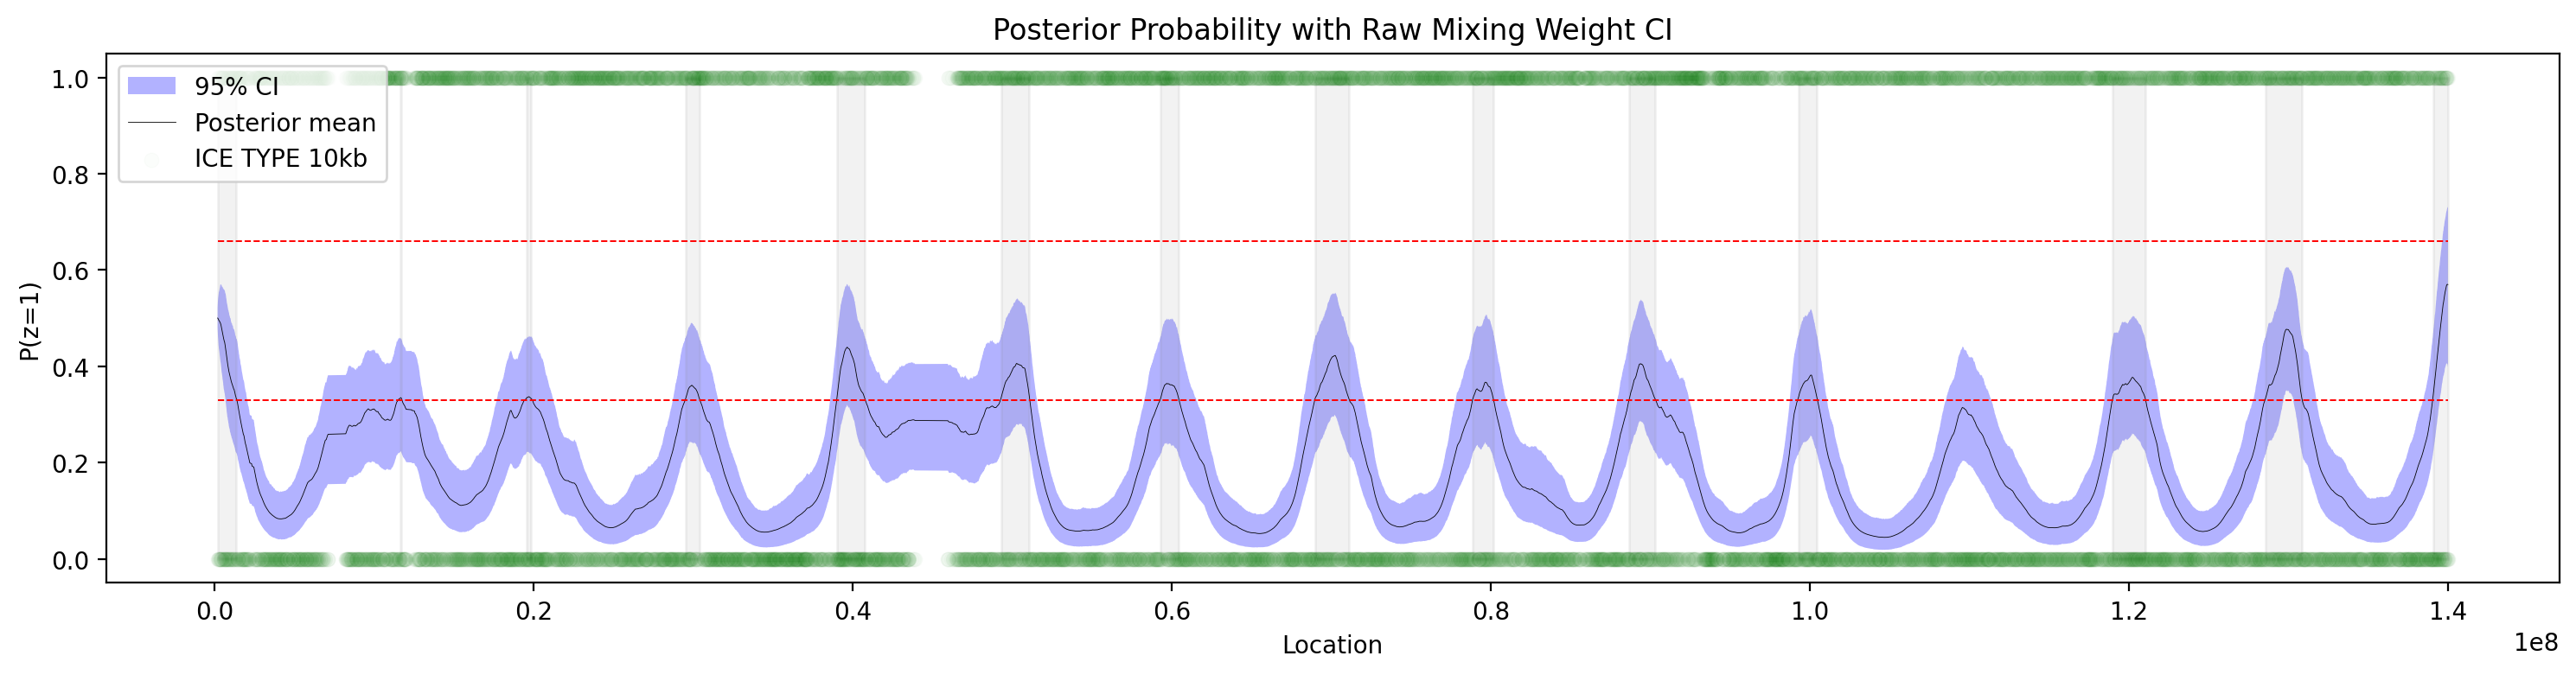

Model: 10kb.Y, non-empty bins: 13424


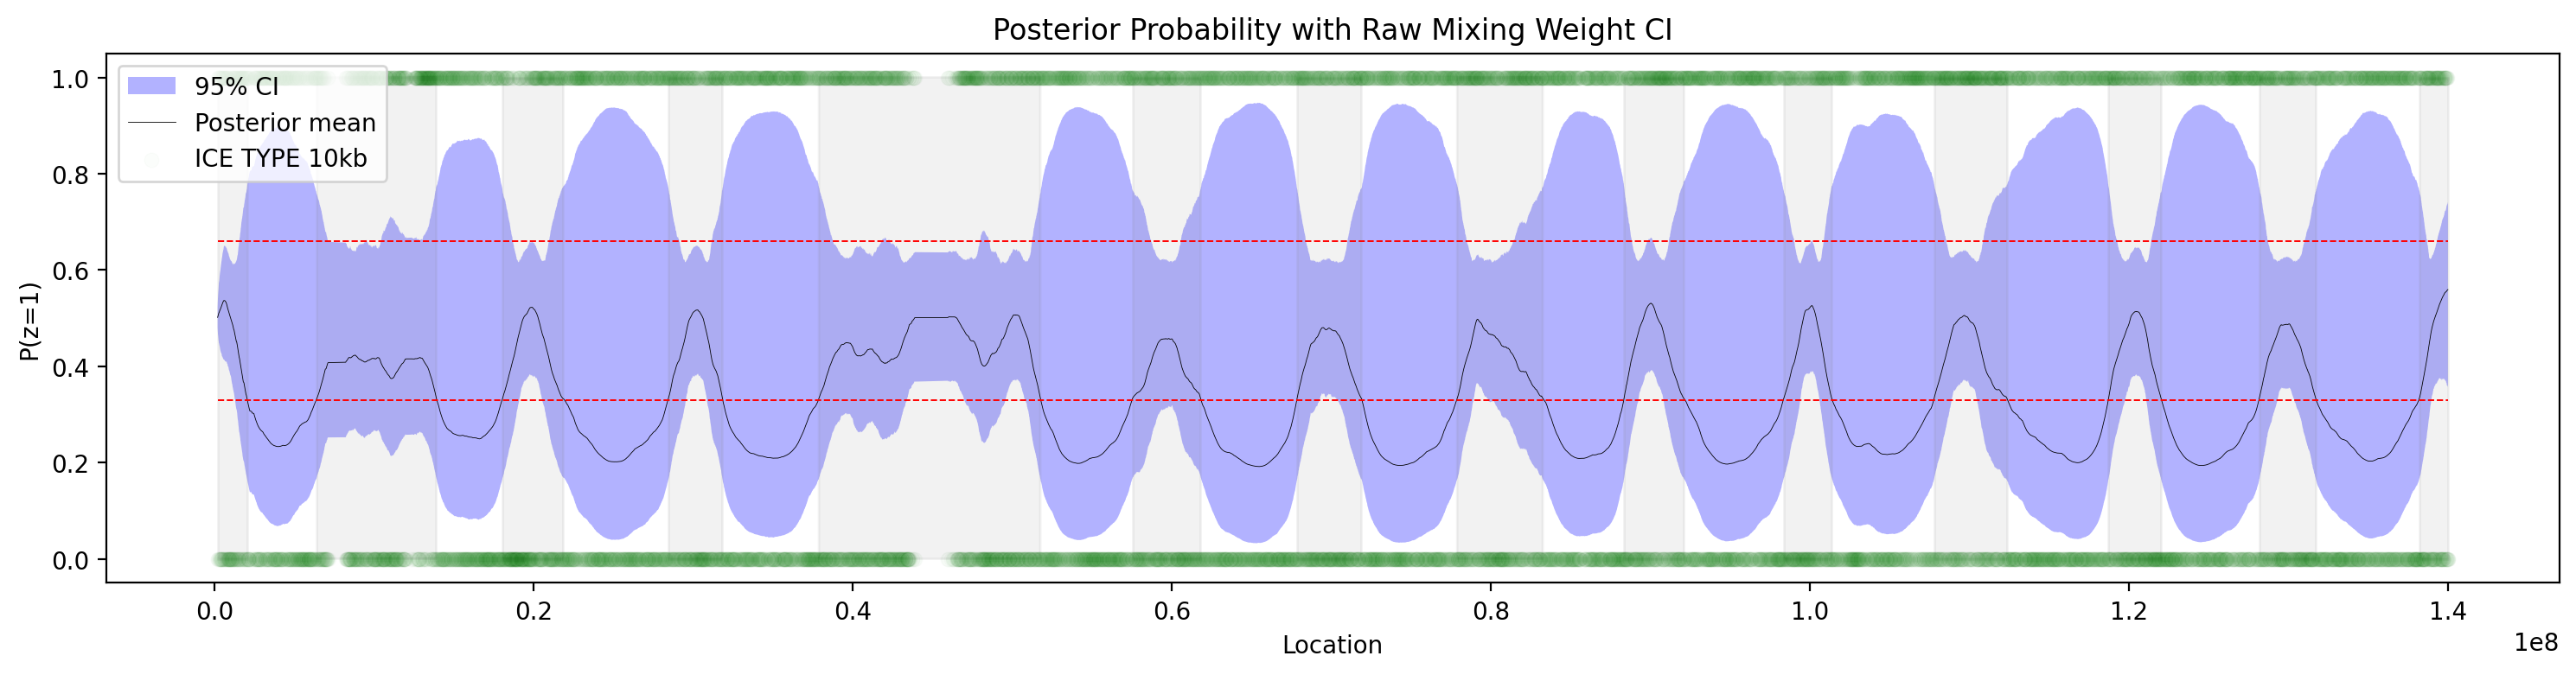

In [5]:
import matplotlib.pyplot as plt

# Set matplotlib to display retina format
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

for name, w_stack in w_vars.items():
    print(f"Model: {name}, non-empty bins: {w_stack.pos.size}")   
    w_mean = w_stack.mean(dim=('sample'))
    w_ci_direct = w_stack.quantile([0.05, 0.95], dim=("sample"))
    w_ci_upper_direct = w_ci_direct.sel(quantile=0.05)
    w_ci_lower_direct = w_ci_direct.sel(quantile=0.95)

    x = w_stack["pos"]

    f, ax = plt.subplots(figsize=(15, 4))

    ax.fill_between(
        x,
        w_ci_lower_direct,
        w_ci_upper_direct,
        alpha=0.3,
        label="95% CI",
        color="blue",
        ec='None'
    )

    x_grey = x.copy()
    x_grey = x_grey.where(
        ~((w_mean < 1/3) | (w_mean > 2/3)),
        np.nan
    )

    # Grey band
    ax.fill_between(
        x, 
        0,
        1,
        where=x_grey.notnull(),
        alpha=0.1,
        color='gray')

    # # Compare e1 predictions
    e1 = traces[name].observed_data.y_hat.values
    hard_assign =  e1 > 0

    ax.plot(x, w_mean, label="Posterior mean", color="black", linewidth=0.3)

    ax.scatter(x, hard_assign, label="ICE TYPE 10kb", color="green", linewidth=0.5, alpha=0.015)

    # Plot the 0.5 line
    ax.hlines([0.66, 0.33], min(x), max(x), color="red", linestyle="--", linewidth=0.7)

    plt.ylabel("P(z=1)")
    plt.xlabel("Location")
    plt.legend(loc='upper left')
    plt.title("Posterior Probability with Raw Mixing Weight CI")
    plt.tight_layout()
    plt.show()

    # zooms = [(10_000_000,19_000_000), (34_000_000, 48_000_000)]

    # f, axs = plt.subplots(len(zooms), figsize=(10, 3*len(zooms)))

    # for i, zoom in enumerate(zooms):
    #     zax = axs[i]
    #     zax.fill_between(
    #         x,
    #         w_ci_lower_direct,
    #         w_ci_upper_direct,
    #         alpha=0.3,
    #         color="blue",
    #         ec='None'
    #     )

    #     # Grey band
    #     zax.fill_between(
    #         x, 
    #         0,
    #         1,
    #         where=x_grey.notnull(),
    #         alpha=0.1,
    #     color='gray')

    #     zax.plot(x, w_mean, label="Posterior mean", color="black", linewidth=0.3)
    #     zax.hlines([0.66, 0.33], min(x), max(x), color="red", linestyle="--", linewidth=0.3)
    #     zax.set_xlim(zoom)
    #     zax.set_title(f"Zoomed In: {zoom}")

    # plt.tight_layout()
    # plt.show()




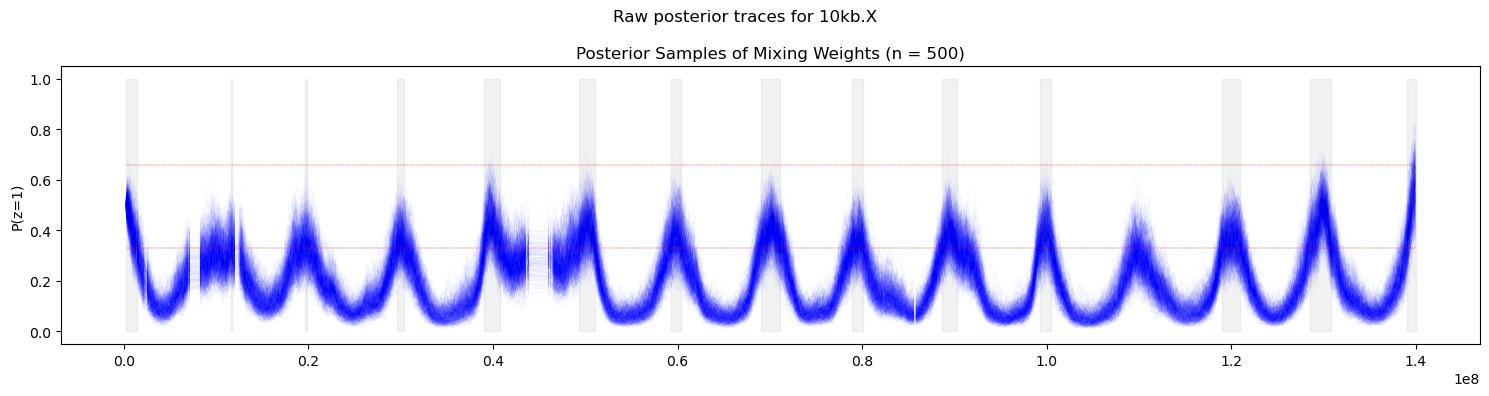

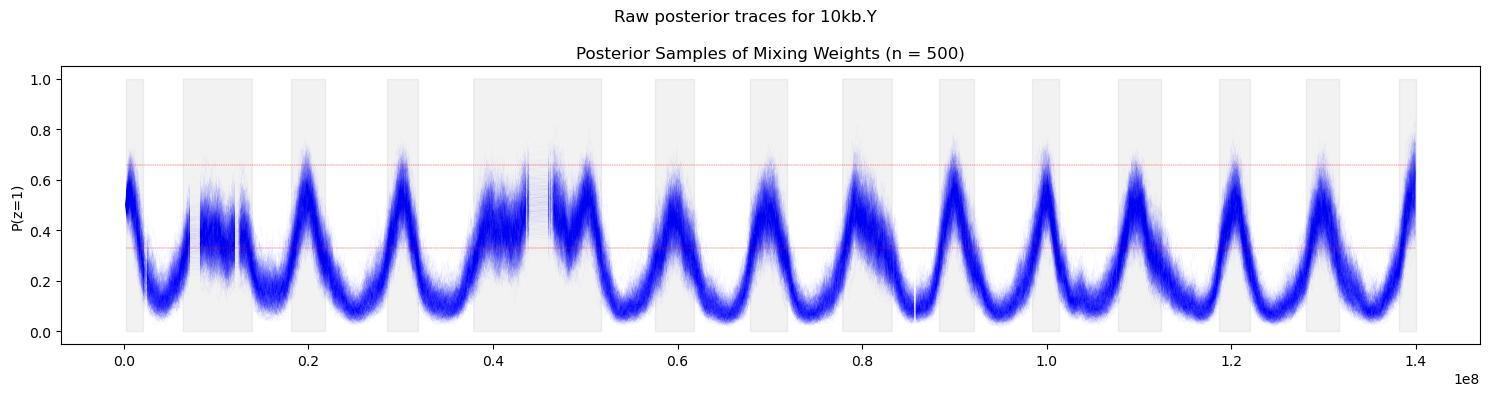

In [6]:
# Plot the all posterior samples of `w` in a single plot
# but start out with a smaller subset
# set the inline display to low dpi
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('jpg')

for name, w_stack in w_vars.items():
    x = w_stack["pos"]
    w_mean = w_stack.mean(dim=('sample'))
    w_subset = w_stack.isel(sample=slice(0, 500))  # Adjust the slice as needed

    f, ax = plt.subplots(figsize=(15, 4))

    plt.suptitle(f"Raw posterior traces for {name}")

    for i in range(w_subset.shape[1]):
        ax.plot(x, w_subset[:,i], alpha=0.1, linewidth=0.05, color="blue")

    # Grey band

    x_grey = x.where(
        ~((w_mean < 1/3) | (w_mean > 2/3)),
        np.nan
    )

    ax.fill_between(
        x, 
        0,
        1,
        where=x_grey.notnull(),
        alpha=0.1,
        color='gray')

    ax.hlines([0.66, 0.33], min(x), max(x), color="red", linestyle="--", linewidth=0.3)
    ax.set_ylabel("P(z=1)")

    plt.title(f"Posterior Samples of Mixing Weights (n = {w_subset.shape[1]})")
    plt.tight_layout()
    plt.show()


Processing model: 10kb.X


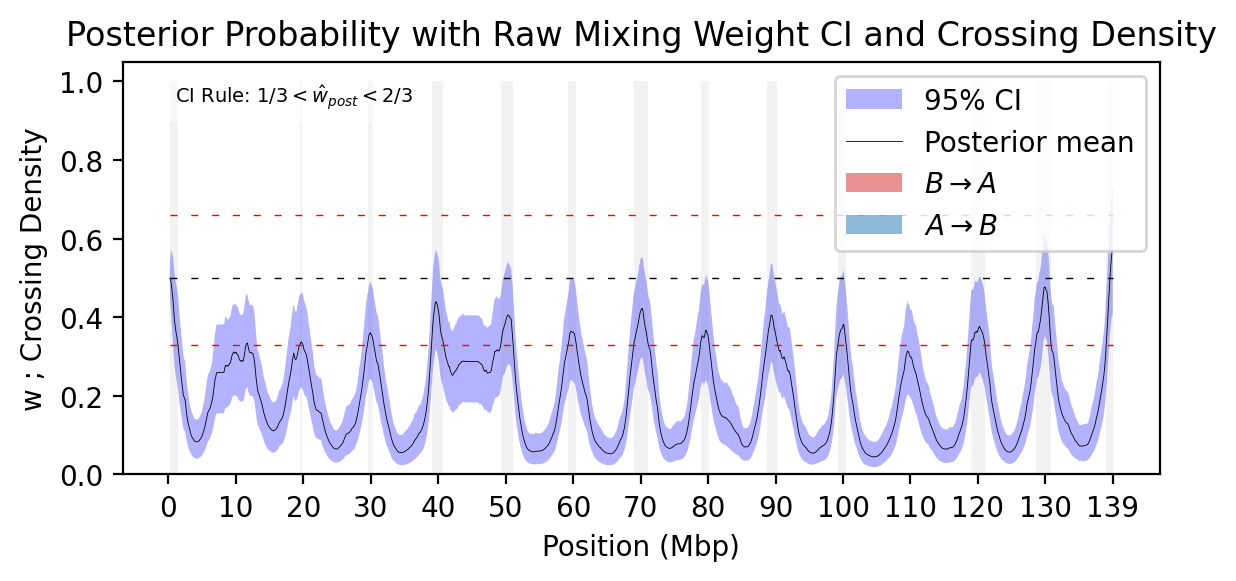

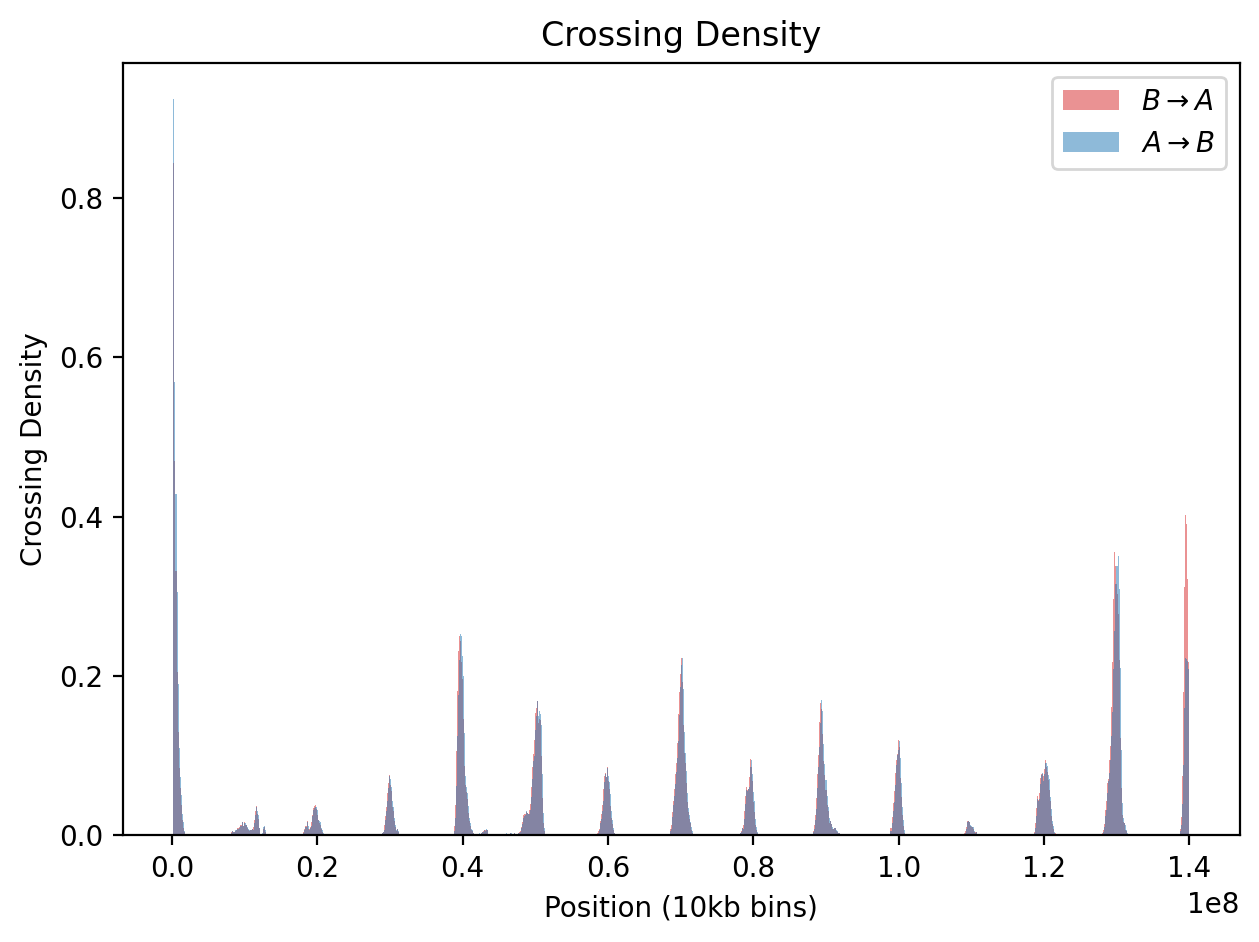

Processing model: 10kb.Y


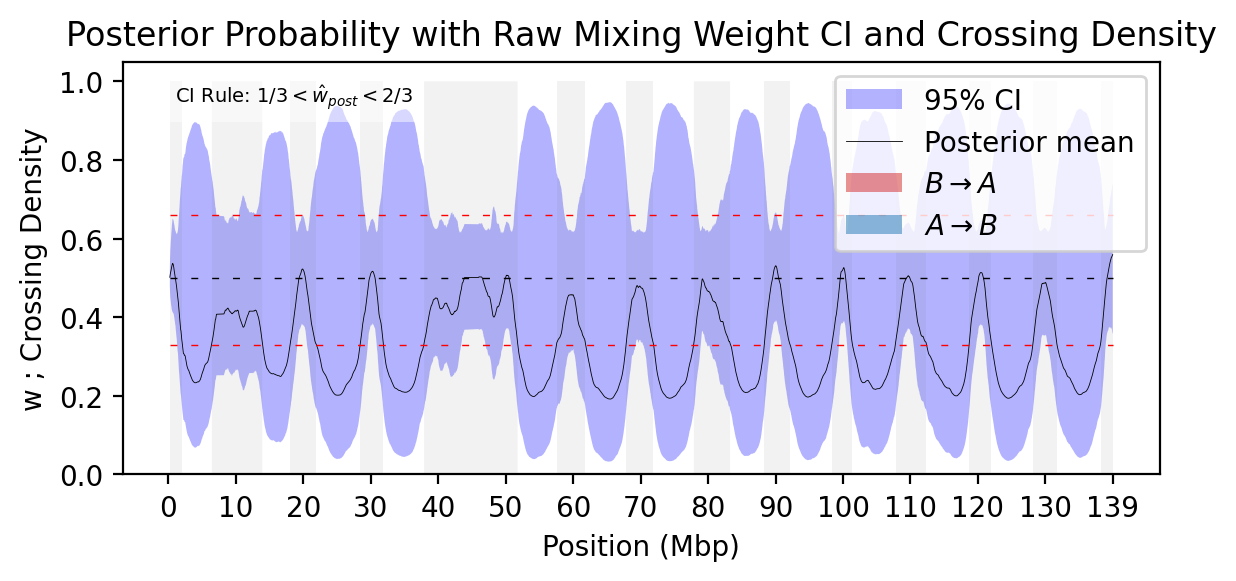

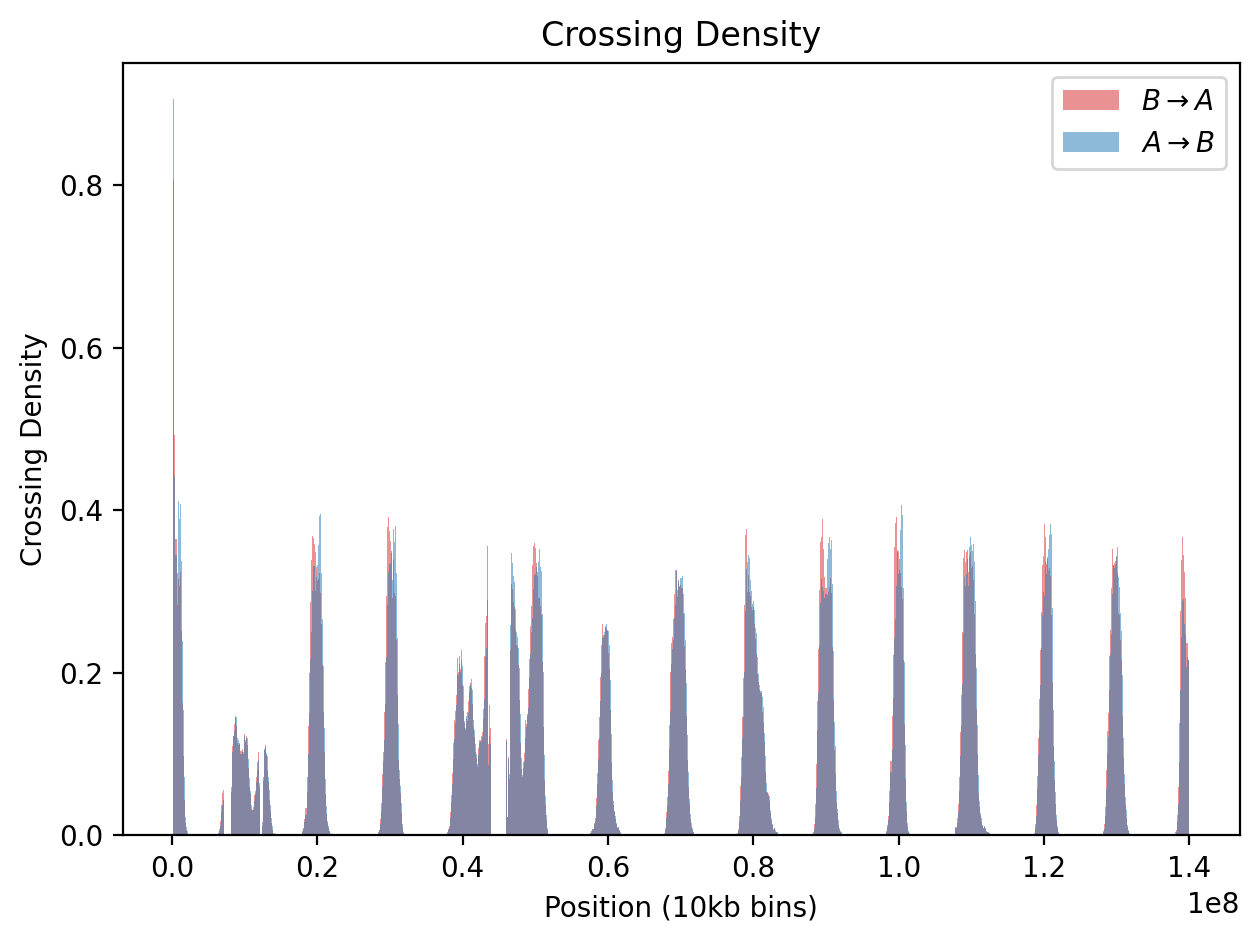

In [10]:
# Positional uncertainty based on counts
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')
import pandas as pd


for name, w_stack in w_vars.items():

    print("Processing model:", name)

    w_mean = w_stack.mean(dim=('sample'))
    w_ci_direct = w_stack.quantile([0.05, 0.95], dim=("sample"))
    w_ci_upper_direct = w_ci_direct.sel(quantile=0.05)
    w_ci_lower_direct = w_ci_direct.sel(quantile=0.95)

    w_np = w_stack.values  # Convert to numpy array
    w_da = w_stack # Use the xarray DataArray directly

    # Set indices for w_np
    w_idx = w_da['pos'].values

    mask = (w_np > 0.5)  # plain ndarray
    mask_next = np.roll(mask, shift=-1, axis=0)  # Shift mask down by one position
    mask_curr = mask[:, :]

    # print(f"""
    # max.w_np: {w_np.max()}
    # mask_curr.shape: {mask_curr.shape}
    #     """)

    cross_down = mask_curr & ~mask_next
    cross_up = ~mask_curr & mask_next

    # Or map the total crossings
    crossings = mask_curr != mask_next

    # Remove the last value where mask_next is wrapped from the first value
    cross_down = cross_down[:-1, :]  # Remove the last row
    cross_up = cross_up[:-1, :]  # Remove the last row
    crossings = crossings[:-1, :]  # Remove the last row

    # Sum the crossings across all samples to get the count of crossings at each position
    crossing_counts = crossings.sum(axis=1)  # Sum across the sample dimension
    cross_up_counts = cross_up.sum(axis=1)  # Sum across the sample dimension
    cross_down_counts = cross_down.sum(axis=1)  # Sum across the sample dimension


    # Calculate the density of crossings
    crossing_density = crossing_counts / w_np.shape[1]
    crossing_density_up = cross_up_counts / w_np.shape[1]
    crossing_density_down = cross_down_counts / w_np.shape[1]

    # # Print shapes of all
    # print("Shape of w_np, mask:", w_np.shape)
    # print("Shape of crossing_counts:", crossing_counts.shape)
    # print("Shape of crossing_density:", crossing_density.shape)
    # print("Shape of crossing_density_up:", crossing_density_up.shape)
    # print("Shape of crossing_density_down:", crossing_density_down.shape)

    df_crossing_density = pd.DataFrame({
        "bin": w_da["pos"].values[:-1],
        "crossing_prop_up": crossing_density_up,
        "crossing_prop_down": crossing_density_down
    })
    df_crossing_density.set_index("bin", inplace=True)
    df_crossing_density
    #df_crossing_density.to_csv("../data/compartment_transitions.10kb.human_sperm_X.tsv", sep="\t")

    x = w_stack["pos"]

    f, ax = plt.subplots(figsize=(6, 3))

    ax.fill_between(
        x,
        w_ci_lower_direct,
        w_ci_upper_direct,
        alpha=0.3,
        label="95% CI",
        color="blue",
        ec='None'
    )

    x_grey = x.copy()
    x_grey = x_grey.where(
        ~((w_mean < 1/3) | (w_mean > 2/3)),
        np.nan
    )

    # Add the CI rule
    ax.text(0.05, 0.95, "CI Rule: $1/3 < \\hat{w}_{post} < 2/3$", 
            transform=ax.transAxes, 
            fontsize=7, 
            verticalalignment='top', 
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

    # Grey band
    ax.fill_between(
        x, 
        0,
        1,
        where=x_grey.notnull(),
        alpha=0.1,
        color='gray',
        ec='None'
        )

    # Plot the posterior mean
    ax.plot(x, w_mean, label="Posterior mean", color="black", linewidth=0.3)

    # Plot the 0.5 line
    ax.hlines(0.5, min(x), max(x), color="black", linestyle=(0, (5, 10)), linewidth=0.5)

    # # Plot the CI rules
    ax.hlines([0.33,0.66], min(x), max(x), color="red", linestyle=(0, (5, 10)), linewidth=0.5)

    # Plot the crossing counts
    ax.bar(x[:-1], crossing_density_up, label="$B \\rightarrow A$", color="tab:red", linewidth=0.3, alpha=0.5)
    ax.bar(x[:-1], crossing_density_down, label="$A \\rightarrow B$", color="tab:blue", linewidth=0.3, alpha=0.5)

    #  make x-axis tick x 10000*1e-6 
    ticks = np.arange(0, np.max(x), step=10_000_000)
    ticks = np.concatenate([ticks,[np.max(x)-1]])  # Ensure the last tick is included
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"{int(tick*1e-6)}" for tick in ticks])

    plt.ylabel("w ; Crossing Density")
    plt.xlabel("Position (Mbp)")
    plt.legend(loc='upper right')
    plt.title("Posterior Probability with Raw Mixing Weight CI and Crossing Density")
    plt.tight_layout()
    plt.show()

    f,ax = plt.subplots()
    ax.hist(df_crossing_density.index,
            weights=df_crossing_density.crossing_prop_up, bins=1000,
            label="$B \\rightarrow A$", color="tab:red", linewidth=0.3, alpha=0.5)
    ax.hist(df_crossing_density.index, 
            weights=df_crossing_density.crossing_prop_down, bins=1000,
            label="$A \\rightarrow B$", color="tab:blue", linewidth=0.3, alpha=0.5)
    ax.set_xlabel("Position (10kb bins)")
    ax.set_ylabel("Crossing Density")
    ax.set_title("Crossing Density")
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()